# Tanimoto Similarity Filtering

**Goal:** Select building blocks from the cleaned ChEMBL dataset that are structurally similar to molecules with known skin permeability measurements.

**Method:** Morgan fingerprints (radius=2, 2048 bits) + Tanimoto similarity threshold ≥ 0.8

**Reference dataset:** HuskinDB + SkinPiX + INRS (~235 molecules with experimental logKp values)

**Input:** 1,094,666 standardized, deduplicated ChEMBL BBs  
**Output:** Focused BB subset similar to skin-permeable molecules

## 1. Imports

In [1]:
import pandas as pd
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
from tqdm import tqdm
import os

output_dir = '/home/nubar/Downloads/Internship_Chemoinfo/01_data/processed'
os.makedirs(output_dir, exist_ok=True)

print('Imports OK')

Imports OK


## 2. Load and merge skin permeability reference datasets

Three curated datasets are combined:
- **HuskinDB** — 129 molecules
- **SkinPiX** — 103 molecules
- **INRS** — 3 molecules

These compounds have experimentally measured skin permeability coefficients (logKp) and serve as the structural reference for BB selection.

In [2]:
huskin  = pd.read_csv('/home/nubar/Downloads/Internship_Chemoinfo/01_data/raw/huskin_depot.csv')
skinpix = pd.read_csv('/home/nubar/Downloads/Internship_Chemoinfo/01_data/raw/skinpix_depot.csv')
inrs    = pd.read_csv('/home/nubar/Downloads/Internship_Chemoinfo/01_data/raw/inrs_depot.csv')

print(f'HuskinDB:  {len(huskin)} molecules')
print(f'SkinPiX:   {len(skinpix)} molecules')
print(f'INRS:      {len(inrs)} molecules')

# Keep only SMILES, add source label
huskin_smi  = huskin[['SMILES']].copy();  huskin_smi['source']  = 'HuskinDB'
skinpix_smi = skinpix[['SMILES']].copy(); skinpix_smi['source'] = 'SkinPiX'
inrs_smi    = inrs[['SMILES']].copy();    inrs_smi['source']    = 'INRS'

# Merge
ref_df = pd.concat([huskin_smi, skinpix_smi, inrs_smi], ignore_index=True)
ref_df = ref_df.drop_duplicates(subset='SMILES').reset_index(drop=True)

print(f'\nTotal reference compounds after deduplication: {len(ref_df)}')

HuskinDB:  129 molecules
SkinPiX:   103 molecules
INRS:      3 molecules

Total reference compounds after deduplication: 214


In [3]:
# Generate Morgan fingerprints for reference compounds
ref_fps = []
valid_ref_smiles = []

for _, row in ref_df.iterrows():
    mol = Chem.MolFromSmiles(row['SMILES'])
    if mol:
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
        ref_fps.append(fp)
        valid_ref_smiles.append(row['SMILES'])

print(f'Valid reference fingerprints generated: {len(ref_fps)}')

Valid reference fingerprints generated: 214


## 3. Load ChEMBL building blocks

Loading the standardized, deduplicated dataset of 1,094,666 compounds.

In [4]:
bb_path = '/home/nubar/Downloads/Internship_Chemoinfo/01_data/standardized/chembl_standardized_dedup.smi'

print('Loading BB dataset...')
bbs = []
with open(bb_path) as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 2:
            bbs.append({'smiles': parts[0], 'chembl_id': parts[1]})

df_bbs = pd.DataFrame(bbs)
print(f'Loaded {len(df_bbs)} building blocks')
df_bbs.head(3)

Loading BB dataset...
Loaded 1094666 building blocks


,smiles,chembl_id
0,[11C-]#[O+],CHEMBL2364719
1,[123IH],CHEMBL1909276
2,[13C](N)(N)=O,CHEMBL2096648


## 4. Tanimoto similarity filtering

For each BB, Morgan fingerprints are computed and compared to all reference compounds using bulk Tanimoto similarity. A BB is retained if its maximum Tanimoto similarity to any reference compound is ≥ 0.8.

**Note:** This processes ~1 million compounds and will take 20-40 minutes.

In [5]:
THRESHOLD = 0.8

passing_smiles = []
passing_ids = []
passing_max_sim = []

print(f'Running Tanimoto filtering (threshold >= {THRESHOLD})...')
print(f'Processing {len(df_bbs)} compounds against {len(ref_fps)} reference molecules')

for _, row in tqdm(df_bbs.iterrows(), total=len(df_bbs), desc='Filtering'):
    mol = Chem.MolFromSmiles(row['smiles'])
    if mol is None:
        continue
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
    sims = DataStructs.BulkTanimotoSimilarity(fp, ref_fps)
    max_sim = max(sims)
    if max_sim >= THRESHOLD:
        passing_smiles.append(row['smiles'])
        passing_ids.append(row['chembl_id'])
        passing_max_sim.append(round(max_sim, 4))

df_focused = pd.DataFrame({
    'smiles': passing_smiles,
    'chembl_id': passing_ids,
    'max_tanimoto': passing_max_sim
})

print(f'\nDone!')
print(f'BBs passing Tanimoto >= {THRESHOLD}: {len(df_focused)}')
print(f'Retention rate: {len(df_focused)/len(df_bbs)*100:.2f}%')

Running Tanimoto filtering (threshold >= 0.8)...
Processing 1094666 compounds against 214 reference molecules


Filtering: 100%|██████████| 1094666/1094666 [03:39<00:00, 4998.33it/s]


Done!
BBs passing Tanimoto >= 0.8: 470
Retention rate: 0.04%


## 5. Save focused BB subset

In [6]:
# Save as SMI for Synt-On
output_smi = f'{output_dir}/chembl_skin_focused.smi'
with open(output_smi, 'w') as f:
    for _, row in df_focused.iterrows():
        f.write(f"{row['smiles']} {row['chembl_id']}\n")

# Save as CSV with similarity scores for reference
output_csv = f'{output_dir}/chembl_skin_focused.csv'
df_focused.to_csv(output_csv, index=False)

print(f'Saved {len(df_focused)} focused BBs')
print(f'SMI file: {output_smi}')
print(f'CSV file: {output_csv}')

Saved 470 focused BBs
SMI file: /home/nubar/Downloads/Internship_Chemoinfo/01_data/processed/chembl_skin_focused.smi
CSV file: /home/nubar/Downloads/Internship_Chemoinfo/01_data/processed/chembl_skin_focused.csv


## 6. Summary statistics

In [7]:
from rdkit.Chem import Descriptors

mws, logps = [], []
for smi in tqdm(df_focused['smiles'], desc='Computing properties'):
    mol = Chem.MolFromSmiles(smi)
    if mol:
        mws.append(Descriptors.MolWt(mol))
        logps.append(Descriptors.MolLogP(mol))

print('\nFocused BB set — property summary:')
print(f'Count:    {len(mws)}')
print(f'MW   — min: {min(mws):.1f}  max: {max(mws):.1f}  mean: {sum(mws)/len(mws):.1f}')
print(f'logP — min: {min(logps):.2f}  max: {max(logps):.2f}  mean: {sum(logps)/len(logps):.2f}')
print(f'\nTanimoto similarity distribution:')
print(f'  Min:  {df_focused["max_tanimoto"].min()}')
print(f'  Max:  {df_focused["max_tanimoto"].max()}')
print(f'  Mean: {df_focused["max_tanimoto"].mean():.4f}')
print(f'  Exact matches (Tanimoto=1.0): {(df_focused["max_tanimoto"]==1.0).sum()}')

Computing properties: 100%|██████████| 470/470 [00:00<00:00, 4003.68it/s]


Focused BB set — property summary:
Count:    470
MW   — min: 17.0  max: 496.5  mean: 278.9
logP — min: -3.20  max: 4.89  mean: 1.94

Tanimoto similarity distribution:
  Min:  0.8
  Max:  1.0
  Mean: 0.9410
  Exact matches (Tanimoto=1.0): 296


In [8]:
# Add this cell to your notebook to investigate
from rdkit.Chem import Descriptors

print("=== Compounds with MW > 250 ===\n")
count = 0
for _, row in df_focused.iterrows():
    mol = Chem.MolFromSmiles(row['smiles'])
    if mol:
        mw = Descriptors.MolWt(mol)
        if mw > 250:
            print(f"SMILES: {row['smiles']}")
            print(f"ChEMBL ID: {row['chembl_id']}")
            print(f"MW: {mw:.1f}")
            print(f"Tanimoto: {row['max_tanimoto']}")
            print("-" * 50)
            count += 1
            if count >= 10:  # show first 10 only
                break

=== Compounds with MW > 250 ===

SMILES: c12[C@]34[C@H]5C=C[C@@H]([C@@H]3Oc1c(ccc2C[C@H]5N(CC4)C)C)O
ChEMBL ID: CHEMBL85089
MW: 283.4
Tanimoto: 0.8039
--------------------------------------------------
SMILES: c12[C@]34[C@H]5C=C[C@@H]([C@@H]3Oc1c(ccc2C[C@H]5N(CC4)C)N)O
ChEMBL ID: CHEMBL333959
MW: 284.4
Tanimoto: 0.8039
--------------------------------------------------
SMILES: C123c4c5c(ccc4CC(C1C=C[C@@H]([C@@H]2O5)O)N(CC3)C)OC(C)(C)C
ChEMBL ID: CHEMBL22919
MW: 341.5
Tanimoto: 0.8036
--------------------------------------------------
SMILES: c12[C@]34[C@H]5C=C[C@@H]([C@@H]3Oc1c(ccc2C[C@H]5N(CC4)C)OCC)O
ChEMBL ID: CHEMBL1712170
MW: 313.4
Tanimoto: 0.8036
--------------------------------------------------
SMILES: C1([C@H]2[C@]34c5c(c(ccc5C[C@H]([C@@H]3CC1)N(CC4)C)OC)O2)=O
ChEMBL ID: CHEMBL1457
MW: 299.4
Tanimoto: 1.0
--------------------------------------------------
SMILES: c12[C@]34[C@@H]5[C@@H](Cc1ccc(c2O[C@H]3[C@H](CC5)O)OC)N(CC4)C
ChEMBL ID: CHEMBL1595
MW: 301.4
Tanimoto: 1.0
------

In [9]:
# Check ChEMBL stored MW vs RDKit calculated MW
import pandas as pd

# Load original ChEMBL CSV
df_chembl = pd.read_csv(
    '/home/nubar/Downloads/Internship_Chemoinfo/01_data/raw/chembl_full_raw.csv',
    sep=';',
    usecols=['Compound ChEMBL ID', 'Molecular Weight'],
    quotechar='"'
)

# Check specific compounds
ids_to_check = ['CHEMBL85089', 'CHEMBL1457', 'CHEMBL1595']
for cid in ids_to_check:
    row = df_chembl[df_chembl['Compound ChEMBL ID'] == cid]
    if len(row) > 0:
        print(f"{cid}: ChEMBL MW = {row['Molecular Weight'].values[0]}")

CHEMBL85089: ChEMBL MW = 283.37
CHEMBL1457: ChEMBL MW = 299.37
CHEMBL1595: ChEMBL MW = 301.39


In [10]:
# Check how many compounds in your focused set have ChEMBL MW > 250
df_chembl = pd.read_csv(
    '/home/nubar/Downloads/Internship_Chemoinfo/01_data/raw/chembl_full_raw.csv',
    sep=';',
    usecols=['Compound ChEMBL ID', 'Molecular Weight'],
    quotechar='"'
)

# Merge with focused set
df_check = df_focused.merge(
    df_chembl.rename(columns={'Compound ChEMBL ID': 'chembl_id', 'Molecular Weight': 'chembl_mw'}),
    on='chembl_id',
    how='left'
)

print(f"Total focused BBs: {len(df_check)}")
print(f"With ChEMBL MW > 250: {(df_check['chembl_mw'] > 250).sum()}")
print(f"With ChEMBL MW <= 250: {(df_check['chembl_mw'] <= 250).sum()}")
print(f"MW not found in ChEMBL CSV: {df_check['chembl_mw'].isna().sum()}")

Total focused BBs: 470
With ChEMBL MW > 250: 264
With ChEMBL MW <= 250: 206
MW not found in ChEMBL CSV: 0


In [11]:
# Check MW distribution of ALL compounds in ChEMBL CSV
df_chembl_all = pd.read_csv(
    '/home/nubar/Downloads/Internship_Chemoinfo/01_data/raw/chembl_full_raw.csv',
    sep=';',
    usecols=['Compound ChEMBL ID', 'Molecular Weight'],
    quotechar='"'
)

df_chembl_all['Molecular Weight'] = pd.to_numeric(df_chembl_all['Molecular Weight'], errors='coerce')

print(f"Total compounds in CSV: {len(df_chembl_all)}")
print(f"MW <= 250: {(df_chembl_all['Molecular Weight'] <= 250).sum()}")
print(f"MW > 250: {(df_chembl_all['Molecular Weight'] > 250).sum()}")
print(f"MW > 500: {(df_chembl_all['Molecular Weight'] > 500).sum()}")
print(f"\nMW distribution:")
print(f"Min: {df_chembl_all['Molecular Weight'].min()}")
print(f"Max: {df_chembl_all['Molecular Weight'].max()}")
print(f"Mean: {df_chembl_all['Molecular Weight'].mean():.1f}")

Total compounds in CSV: 1348305
MW <= 250: 122020
MW > 250: 1226285
MW > 500: 11765

MW distribution:
Min: 12.01
Max: 1726.21
Mean: 356.5


In [12]:
from rdkit.Chem import Descriptors

print("Applying MW <= 250 filter to standardized dataset...")

passing = []
with open('/home/nubar/Downloads/Internship_Chemoinfo/01_data/standardized/chembl_standardized_dedup.smi') as f:
    for line in tqdm(f, total=1094666, desc='Filtering'):
        parts = line.strip().split()
        if len(parts) >= 2:
            mol = Chem.MolFromSmiles(parts[0])
            if mol and Descriptors.MolWt(mol) <= 250:
                passing.append(line.strip())

print(f'Compounds with MW <= 250: {len(passing)}')

Applying MW <= 250 filter to standardized dataset...


Filtering: 100%|██████████| 1094666/1094666 [01:25<00:00, 12826.73it/s]

Compounds with MW <= 250: 100150


In [14]:
import pandas as pd

df_pred = pd.read_csv('/home/nubar/Downloads/Internship_Chemoinfo/03_synthon/outputs/skin_focused_enumeration/CSV12964.csv', 
                      sep=';', 
                      quotechar='"')

print(f'Total predictions: {len(df_pred)}')
print(f'\nColumns: {list(df_pred.columns)}')
print(f'\nlogKp statistics:')
print(df_pred['Average on AD'].describe())
print(f'\nPrediction confidence distribution:')
print(df_pred['Prediction confidence'].value_counts())

Total predictions: 100

Columns: ['Compound Id', 'Compound Name', 'Model1 AD', 'Model1', 'Model2 AD', 'Model2', 'Model3 AD', 'Model3', 'Model4 AD', 'Model4', 'Model5 AD', 'Model5', 'Average on AD', '# of Applied models', 'Prediction confidence', 'Comments']

logKp statistics:
count    100.00000
mean      -3.10230
std        0.03558
min       -3.21200
25%       -3.12125
50%       -3.10100
75%       -3.07400
max       -3.03500
Name: Average on AD, dtype: float64

Prediction confidence distribution:
Prediction confidence
Good       96
Low         2
Average     2
Name: count, dtype: int64


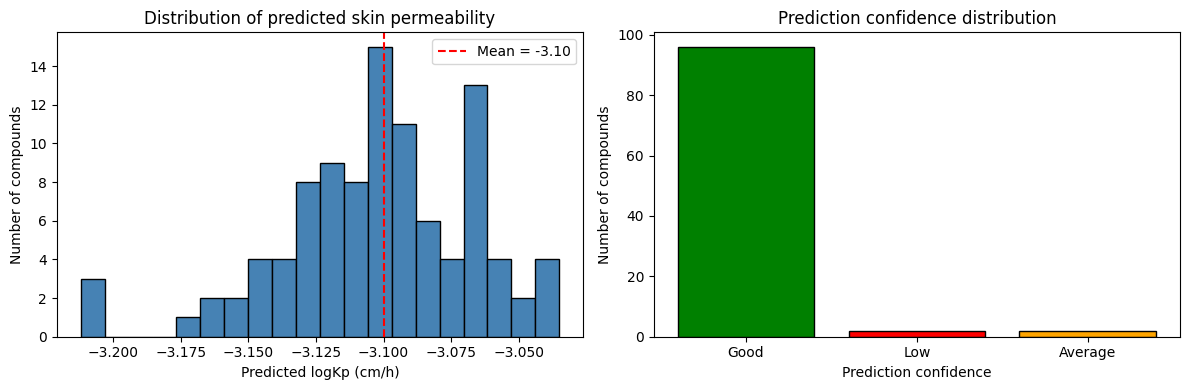

Plot saved!


In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# logKp distribution
axes[0].hist(df_pred['Average on AD'], bins=20, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Predicted logKp (cm/h)')
axes[0].set_ylabel('Number of compounds')
axes[0].set_title('Distribution of predicted skin permeability')
axes[0].axvline(x=-3.10, color='red', linestyle='--', label=f'Mean = -3.10')
axes[0].legend()

# Confidence distribution
conf_counts = df_pred['Prediction confidence'].value_counts()
colors = ['green' if c == 'Good' else 'orange' if c == 'Average' else 'red' 
          for c in conf_counts.index]
axes[1].bar(conf_counts.index, conf_counts.values, color=colors, edgecolor='black')
axes[1].set_xlabel('Prediction confidence')
axes[1].set_ylabel('Number of compounds')
axes[1].set_title('Prediction confidence distribution')

plt.tight_layout()
plt.savefig('/home/nubar/Downloads/Internship_Chemoinfo/04_results/logKp_predictions.png', dpi=150)
plt.show()
print('Plot saved!')